# Laboratorio 9 - Redes Neuronales

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import pandas as pd
import pyreadr
from sklearn import datasets
from sklearn.model_selection import train_test_split
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.compose import make_column_selector as selector #Para seleccionar de forma automática las variables numéricas y categóricas
from sklearn.preprocessing import OneHotEncoder #Para codificar las variables categóricas usando dummies
from sklearn.preprocessing import StandardScaler #Para normalizar las variables numéricas
from sklearn.compose import ColumnTransformer #Modifica las columnas usando los preprocesadores
from sklearn.pipeline import make_pipeline #Planifica una secuencia de procesos
from sklearn import set_config #Para mostrar graficamente el pipeline
from sklearn.model_selection import GridSearchCV

set_config(display='diagram')
#Metrics
from sklearn.metrics import make_scorer, accuracy_score,precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score

In [3]:
result = pyreadr.read_r('listings.RData')
df = result[list(result.keys())[0]]

### 1. Conjuntos Train y Test

In [4]:
#Limpieza de datos

df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

df = df.dropna(subset=["price"])

In [5]:
def categorize_price(price):
    if price <= 120:
        return "Economico"
    elif price <= 326:
        return "Intermedio"
    else:
        return "Caro"

df["price_category"] = df["price"].apply(categorize_price)

/var/folders/dc/_dt3fhrs48n2b_4mmncch3440000gp/T/ipykernel_24458/3701250134.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["price_category"] = df["price"].apply(categorize_price)


In [6]:
df['price_category'].value_counts()

price_category
Intermedio    37882
Economico     19310
Caro          19054
Name: count, dtype: int64

In [7]:
# variables predictoras
X = df.drop(columns=["price", "price_category"])

# variable objetivo (clasificación)
y = df["price_category"]

In [8]:

pd.Series(y).value_counts(normalize=True)

price_category
Intermedio    0.496839
Economico     0.253259
Caro          0.249902
Name: proportion, dtype: float64

In [9]:
# variables importantes
X = df[[
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "review_scores_rating"
]]

y = df["price_category"]

# imputar
from sklearn.impute import SimpleImputer
X = SimpleImputer(strategy="mean").fit_transform(X)

# split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


### 2. Exploración y Transformación

In [10]:
# escalar
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Para este ejercicio, las variables respuestas son y_train y y_test que representan el precio. Estas representan:

- Económico
- Intermedio
- Caro

### 3. Crear DOS modelos de RNA (clasificación)

In [11]:
#SIMPLE

mlp1 = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation='relu',
    max_iter=200,
    random_state=42
)

mlp1.fit(X_train_scaled, y_train)

y_pred_mlp1 = mlp1.predict(X_test_scaled)

In [12]:
#COMPLEJO

mlp2 = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='tanh',
    max_iter=200,
    verbose=True,
    random_state=42
)

mlp2.fit(X_train_scaled, y_train)

y_pred_mlp2 = mlp2.predict(X_test_scaled)

Iteration 1, loss = 0.84202573
Iteration 2, loss = 0.82973517
Iteration 3, loss = 0.82221949
Iteration 4, loss = 0.81633266
Iteration 5, loss = 0.81316399
Iteration 6, loss = 0.81055420
Iteration 7, loss = 0.80906525
Iteration 8, loss = 0.80806362
Iteration 9, loss = 0.80706018
Iteration 10, loss = 0.80679601
Iteration 11, loss = 0.80565499
Iteration 12, loss = 0.80490473
Iteration 13, loss = 0.80348295
Iteration 14, loss = 0.80313862
Iteration 15, loss = 0.80203126
Iteration 16, loss = 0.80196565
Iteration 17, loss = 0.80012388
Iteration 18, loss = 0.80013602
Iteration 19, loss = 0.79965830
Iteration 20, loss = 0.79845913
Iteration 21, loss = 0.79757413
Iteration 22, loss = 0.79639811
Iteration 23, loss = 0.79594920
Iteration 24, loss = 0.79416339
Iteration 25, loss = 0.79355148
Iteration 26, loss = 0.79171866
Iteration 27, loss = 0.79076285
Iteration 28, loss = 0.78907113
Iteration 29, loss = 0.78748576
Iteration 30, loss = 0.78533768
Iteration 31, loss = 0.78443252
Iteration 32, los

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### 4. Valores modelos

In [13]:
print("Modelo 1 entrenado con: ", y_pred_mlp1)
print("\nModelo 2 entrenado con: ", y_pred_mlp2)

Modelo 1 entrenado con:  ['Intermedio' 'Economico' 'Caro' ... 'Intermedio' 'Economico' 'Caro']

Modelo 2 entrenado con:  ['Intermedio' 'Economico' 'Intermedio' ... 'Intermedio' 'Economico'
 'Intermedio']


### 5. Matrices de confusión

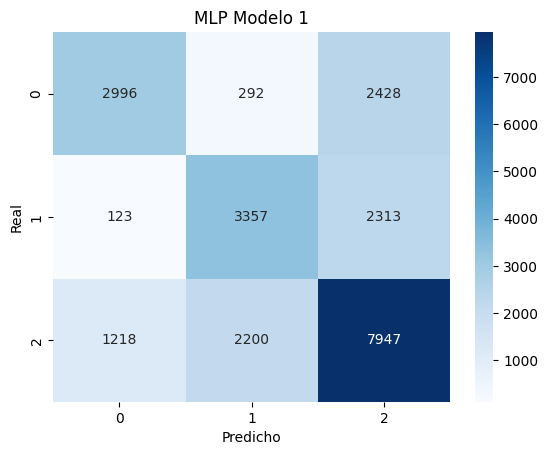

              precision    recall  f1-score   support

        Caro       0.69      0.52      0.60      5716
   Economico       0.57      0.58      0.58      5793
  Intermedio       0.63      0.70      0.66     11365

    accuracy                           0.63     22874
   macro avg       0.63      0.60      0.61     22874
weighted avg       0.63      0.63      0.62     22874



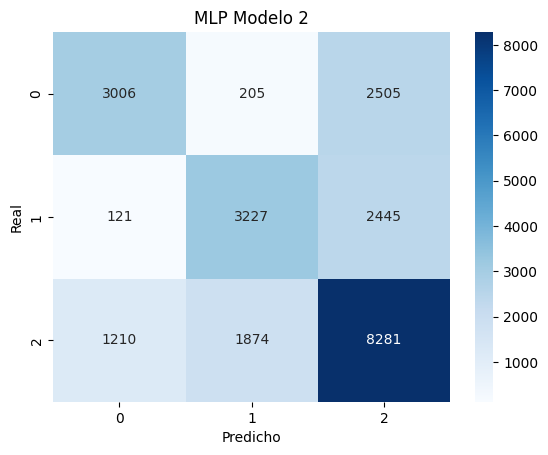

              precision    recall  f1-score   support

        Caro       0.69      0.53      0.60      5716
   Economico       0.61      0.56      0.58      5793
  Intermedio       0.63      0.73      0.67     11365

    accuracy                           0.63     22874
   macro avg       0.64      0.60      0.62     22874
weighted avg       0.64      0.63      0.63     22874



In [14]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()

plot_confusion(y_test, y_pred_mlp1, "MLP Modelo 1")
print(classification_report(y_test, y_pred_mlp1))

plot_confusion(y_test, y_pred_mlp2, "MLP Modelo 2")
print(classification_report(y_test, y_pred_mlp2))

### 6. Comparación resultados

In [15]:
acc1 = accuracy_score(y_test, y_pred_mlp1)
acc2 = accuracy_score(y_test, y_pred_mlp2)

print("Modelo 1 Accuracy:", acc1)
print("Modelo 2 Accuracy:", acc2)

Modelo 1 Accuracy: 0.6251639415930751
Modelo 2 Accuracy: 0.6345195418378946


Se compararon dos modelos de redes neuronales con diferentes arquitecturas. El modelo simple, con una sola capa oculta, obtuvo una precisión de aproximadamente 0.625, mientras que el modelo más complejo, con dos capas ocultas, alcanzó una precisión de aproximadamente 0.635.

Esto indica que el incremento en la complejidad del modelo permite capturar ligeramente mejor los patrones presentes en los datos, sugiriendo la existencia de relaciones no lineales. Sin embargo, la mejora es marginal, lo que implica que el problema no requiere una arquitectura altamente compleja.

En consecuencia, el modelo más complejo presenta un mejor desempeño, aunque el modelo simple sigue siendo competitivo y más eficiente computacionalmente.

### 7. Análisis de sobreajuste en los modelos

In [16]:
y_train_pred_mlp1 = mlp1.predict(X_train_scaled)
y_train_pred_mlp2 = mlp2.predict(X_train_scaled)

In [17]:
acc1_train = accuracy_score(y_train, y_train_pred_mlp1)
acc2_train = accuracy_score(y_train, y_train_pred_mlp2)

In [18]:
print("Modelo 1 - Train:", acc1_train, "Test:", acc1)
print("Modelo 2 - Train:", acc2_train, "Test:", acc2)

Modelo 1 - Train: 0.6242786479802144 Test: 0.6251639415930751
Modelo 2 - Train: 0.6394551450198606 Test: 0.6345195418378946


Al analizar el sobreajuste es posible identificar que ambos modelos generalizan bien, aunque el rendimiento es moderado, lo que indica un posible underfitting.

### 8. Modelo de clasificación - modificación de parámetros

### 9. Precio del listing como variable respuesta

### 10. Modelos de Regersión con redes neuronales

### 11. Comparación de los dos modelos

### 12. Análisis de sobreajuste y curva de aprendizaje